# **PROYECTO FINAL — TEMAS DE OPTIMIZACIÓN LINEAL**
## Problema: Uso Eficiente de Espacios Universitarios
## Subcaso: OL1 e IA1 compitiendo por SC067-P214 y PC012-P96A en F1 (Lunes 7-9)
### Elaborado por: Sara Mejia y Jeronimo Arcila

In [21]:
import pulp
import numpy as np
import time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyArrowPatch

### 1. DATOS DEL SUBCASO

In [13]:
# Cursos
cursos = {
    "OL1": {"estudiantes": 18, "prioridad": 3},
    "IA1": {"estudiantes": 22, "prioridad": 3},
}
# Salones disponibles en F1
salones = {
    "SC067-P214":  {"capacidad": 25},
    "PC012-P96A":  {"capacidad": 20},
}
# Compatibilidad curso-salón (1 si el salón tiene capacidad suficiente, 0 si no)
# OL1 (18 est.) → cabe en ambos salones
# IA1 (22 est.) → solo cabe en SC067-P214 (cap 25); NO en PC012-P96A (cap 20)
compatibilidad = {
    ("OL1", "SC067-P214"): 1,
    ("OL1", "PC012-P96A"): 1,
    ("IA1", "SC067-P214"): 1,
    ("IA1", "PC012-P96A"): 0,   # 22 > 20 → inviable
}
print("=" * 60)
print("  OPTIMIZACIÓN DE ESPACIOS — SUBCASO F1 (Lunes 7:00-9:00)")
print("=" * 60)

print("\n DATOS DEL PROBLEMA")
print("-" * 40)
for curso, datos in cursos.items():
    coef = datos["prioridad"] * datos["estudiantes"]
    print(f"  {curso}: {datos['estudiantes']} estudiantes | "
          f"prioridad {datos['prioridad']} | coef. F.O. = {coef}")

print("\n  SALONES DISPONIBLES EN F1")
print("-" * 40)
for salon, datos in salones.items():
    print(f"  {salon}: capacidad {datos['capacidad']}")

print("\n COMPATIBILIDAD CURSO-SALÓN")
print("-" * 40)
for (curso, salon), val in compatibilidad.items():
    estado = " viable" if val else " no viable (capacidad insuficiente)"
    print(f"  {curso} → {salon}: {estado}")


  OPTIMIZACIÓN DE ESPACIOS — SUBCASO F1 (Lunes 7:00-9:00)

 DATOS DEL PROBLEMA
----------------------------------------
  OL1: 18 estudiantes | prioridad 3 | coef. F.O. = 54
  IA1: 22 estudiantes | prioridad 3 | coef. F.O. = 66

  SALONES DISPONIBLES EN F1
----------------------------------------
  SC067-P214: capacidad 25
  PC012-P96A: capacidad 20

 COMPATIBILIDAD CURSO-SALÓN
----------------------------------------
  OL1 → SC067-P214:  viable
  OL1 → PC012-P96A:  viable
  IA1 → SC067-P214:  viable
  IA1 → PC012-P96A:  no viable (capacidad insuficiente)


### 2. DEFINICIÓN DEL MODELO LP (RELAJACIÓN CONTINUA)

In [4]:
modelo = pulp.LpProblem("Asignacion_Espacios_F1", pulp.LpMaximize)

# Variables de decisión: x[curso, salon] ∈ [0, 1]
x = {}
for curso in cursos:
    for salon in salones:
        nombre = f"x_{curso}_{salon.replace('-','_').replace(' ','_')}"
        x[(curso, salon)] = pulp.LpVariable(
            nombre,
            lowBound=0,
            upBound=compatibilidad[(curso, salon)],  # 0 si incompatible
            cat="Continuous"
        )

# Nomenclatura para mostrar:
# x1 = x[OL1, SC067-P214]
# x2 = x[OL1, PC012-P96A]
# x3 = x[IA1, SC067-P214]
# x4 = x[IA1, PC012-P96A]  → acotada a 0 por incompatibilidad

### 3. FUNCIÓN OBJETIVO

In [5]:
# max Z = p_i * e_i * x_ij para todo i, j
modelo += pulp.lpSum(
    cursos[curso]["prioridad"] * cursos[curso]["estudiantes"] * x[(curso, salon)]
    for curso in cursos
    for salon in salones
), "FuncionObjetivo"


### 4. RESTRICCIONES

In [6]:
# R1: Exclusividad SC067-P214 — un solo curso por salón en F1
modelo += (
    x[("OL1", "SC067-P214")] + x[("IA1", "SC067-P214")] <= 1,
    "R1_exclusividad_SC067"
)

# R2: Exclusividad PC012-P96A — un solo curso por salón en F1
modelo += (
    x[("OL1", "PC012-P96A")] + x[("IA1", "PC012-P96A")] <= 1,
    "R2_exclusividad_PC012"
)

# R3: OL1 se asigna a máximo un salón en F1
modelo += (
    x[("OL1", "SC067-P214")] + x[("OL1", "PC012-P96A")] <= 1,
    "R3_OL1_max_un_salon"
)

# R4: IA1 se asigna a máximo un salón en F1
modelo += (
    x[("IA1", "SC067-P214")] + x[("IA1", "PC012-P96A")] <= 1,
    "R4_IA1_max_un_salon"
)

### 5. RESOLUCIÓN

In [7]:
estado = modelo.solve(pulp.PULP_CBC_CMD(msg=0))
print(f"  Estado: {pulp.LpStatus[modelo.status]}")

  Estado: Optimal


### 6. SOLUCIÓN ÓPTIMA

In [8]:
print("\n SOLUCIÓN ÓPTIMA")
print("-" * 40)

etiquetas = {
    ("OL1", "SC067-P214"): "x₁",
    ("OL1", "PC012-P96A"): "x₂",
    ("IA1", "SC067-P214"): "x₃",
    ("IA1", "PC012-P96A"): "x₄",
}

for (curso, salon), var in x.items():
    etiqueta = etiquetas[(curso, salon)]
    val = pulp.value(var)
    asignado = "← ASIGNADO" if round(val, 4) == 1.0 else ""
    print(f"  {etiqueta} = x[{curso}, {salon}] = {val:.4f}  {asignado}")

Z = pulp.value(modelo.objective)
print(f"\n  Z óptimo = {Z:.2f}")

print("\n INTERPRETACIÓN")
print("-" * 40)
for (curso, salon), var in x.items():
    if round(pulp.value(var), 4) == 1.0:
        print(f"  → {curso} asignado a {salon} en F1 (Lunes 7:00–9:00)")



 SOLUCIÓN ÓPTIMA
----------------------------------------
  x₁ = x[OL1, SC067-P214] = -0.0000  
  x₂ = x[OL1, PC012-P96A] = 1.0000  ← ASIGNADO
  x₃ = x[IA1, SC067-P214] = 1.0000  ← ASIGNADO
  x₄ = x[IA1, PC012-P96A] = 0.0000  

  Z óptimo = 120.00

 INTERPRETACIÓN
----------------------------------------
  → OL1 asignado a PC012-P96A en F1 (Lunes 7:00–9:00)
  → IA1 asignado a SC067-P214 en F1 (Lunes 7:00–9:00)


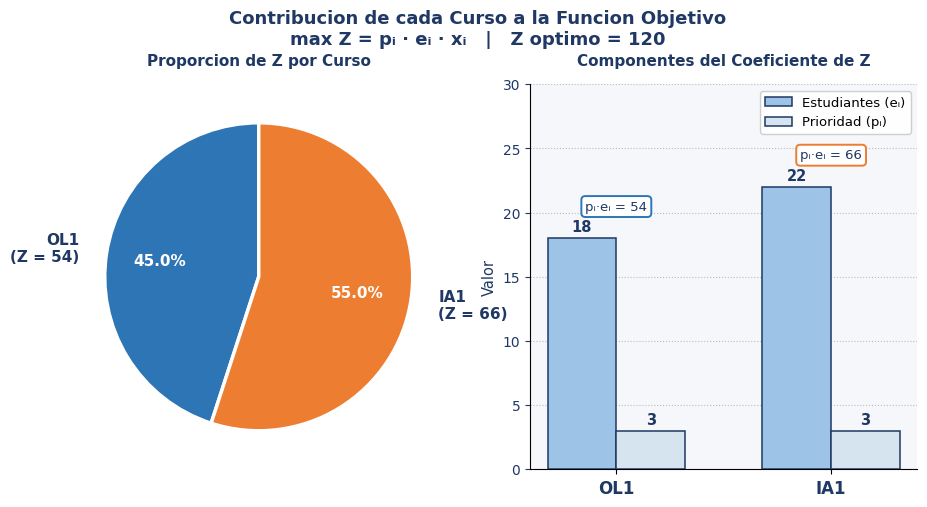

In [28]:
# =============================================================================
# DATOS
# =============================================================================

NAVY    = "#1F3864"
BLUE    = "#2E75B6"
CYAN    = "#9DC3E6"
GREEN   = "#70AD47"
ORANGE  = "#ED7D31"
GRAY    = "#F5F7FA"
WHITE   = "#FFFFFF"
LIGHT   = "#D6E4F0"

cursos = {
    "OL1": {
        "estudiantes": 18,
        "prioridad":   3,
        "salon":       "PC012-P96A",
        "asignado":    True,
    },
    "IA1": {
        "estudiantes": 22,
        "prioridad":   3,
        "salon":       "SC067-P214",
        "asignado":    True,
    },
}

for curso, datos in cursos.items():
    datos["coef_fo"]      = datos["prioridad"] * datos["estudiantes"]
    datos["contribucion"] = datos["coef_fo"] * (1 if datos["asignado"] else 0)

Z_total     = sum(d["contribucion"] for d in cursos.values())
nombres     = list(cursos.keys())
coefs       = [cursos[c]["coef_fo"]      for c in nombres]
contribs    = [cursos[c]["contribucion"] for c in nombres]
estudiantes = [cursos[c]["estudiantes"]  for c in nombres]
prioridades = [cursos[c]["prioridad"]    for c in nombres]
porcentajes = [100 * c / Z_total        for c in contribs]

colores_barra = [BLUE, ORANGE]

# =============================================================================
# FIGURA: 1 fila, 2 columnas (torta | barras agrupadas)
# =============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5), facecolor=WHITE)

fig.suptitle(
    "Contribucion de cada Curso a la Funcion Objetivo\n"
    "max Z = p\u1d62 \u00b7 e\u1d62 \u00b7 x\u1d62   |   Z optimo = 120",
    fontsize=13, fontweight="bold", color=NAVY, y=1.03
)

# =============================================================================
# PANEL IZQUIERDO: Torta de proporcion
# =============================================================================

ax1.set_facecolor(GRAY)

wedges, texts, autotexts = ax1.pie(
    contribs,
    labels=[f"{n}\n(Z = {int(c)})" for n, c in zip(nombres, contribs)],
    colors=colores_barra,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(edgecolor=WHITE, linewidth=2.5),
    textprops=dict(fontsize=11, color=NAVY, fontweight="bold"),
    pctdistance=0.65,
    labeldistance=1.18,
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_color(WHITE)
    at.set_fontweight("bold")

ax1.set_title("Proporcion de Z por Curso", fontsize=11,
              fontweight="bold", color=NAVY, pad=14)

# =============================================================================
# PANEL DERECHO: Barras agrupadas (estudiantes vs prioridad)
# =============================================================================

ax2.set_facecolor(GRAY)

x     = np.arange(len(nombres))
ancho = 0.32

b_est = ax2.bar(x - ancho / 2, estudiantes, ancho,
                label="Estudiantes (e\u1d62)",
                color=CYAN, edgecolor=NAVY, linewidth=1.1, zorder=3)
b_pri = ax2.bar(x + ancho / 2, prioridades, ancho,
                label="Prioridad (p\u1d62)",
                color=LIGHT, edgecolor=NAVY, linewidth=1.1, zorder=3)

for bar in list(b_est) + list(b_pri):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{int(bar.get_height())}",
        ha="center", va="bottom",
        fontsize=10.5, fontweight="bold", color=NAVY
    )

# Anotacion del coeficiente resultante sobre cada curso
for i, (nombre, coef) in enumerate(zip(nombres, coefs)):
    ax2.annotate(
        f"p\u1d62\u00b7e\u1d62 = {coef}",
        xy=(i, max(estudiantes[i], prioridades[i]) + 2.2),
        ha="center", fontsize=9.5, color=NAVY,
        bbox=dict(boxstyle="round,pad=0.3", fc=WHITE,
                  ec=colores_barra[i], lw=1.4)
    )

ax2.set_xticks(x)
ax2.set_xticklabels(nombres, fontsize=12, color=NAVY, fontweight="bold")
ax2.set_ylim(0, 30)
ax2.set_title("Componentes del Coeficiente de Z", fontsize=11,
              fontweight="bold", color=NAVY, pad=14)
ax2.set_ylabel("Valor", fontsize=10.5, color=NAVY)
ax2.legend(fontsize=9.5, framealpha=0.95, loc="upper right")
ax2.grid(axis="y", linestyle=":", alpha=0.5, color="gray", zorder=0)
ax2.set_axisbelow(True)
ax2.tick_params(axis="y", colors=NAVY)
ax2.spines[["top", "right"]].set_visible(False)


### 7. RESTRICCIONES ACTIVAS Y PRECIOS SOMBRA

In [14]:
print("\n PRECIOS SOMBRA (VARIABLES DUALES)")
print("-" * 60)
print(f"  {'Restricción':<30} {'Precio sombra':>15} {'¿Activa?':>10}")
print(f"  {'-'*30} {'-'*15} {'-'*10}")

restricciones_info = {
    "R1_exclusividad_SC067": "R1: exclusividad SC067-P214",
    "R2_exclusividad_PC012": "R2: exclusividad PC012-P96A",
    "R3_OL1_max_un_salon":   "R3: OL1 en máx. un salón",
    "R4_IA1_max_un_salon":   "R4: IA1 en máx. un salón",
}

for nombre, etiqueta in restricciones_info.items():
    restriccion = modelo.constraints[nombre]
    precio_sombra = restriccion.pi
    holgura = restriccion.slack
    activa = " Sí" if abs(holgura) < 1e-6 else "No"
    print(f"  {etiqueta:<30} {precio_sombra:>15.2f} {activa:>10}")



 PRECIOS SOMBRA (VARIABLES DUALES)
------------------------------------------------------------
  Restricción                      Precio sombra   ¿Activa?
  ------------------------------ --------------- ----------
  R1: exclusividad SC067-P214              54.00         Sí
  R2: exclusividad PC012-P96A              -0.00         Sí
  R3: OL1 en máx. un salón                 -0.00         Sí
  R4: IA1 en máx. un salón                 -0.00         Sí


## Bonos

### 1. IMPLEMENTACIÓN PARCIAL DEL MÉTODO SIMPLEX

In [16]:
# Nombres de columnas: [x1, x2, x3, x4, s1, s2, s3, s4, b]
COLUMNAS = ["x1", "x2", "x3", "x4", "s1", "s2", "s3", "s4", "b"]
ETIQUETAS = {
    "x1": "x[OL1, SC067-P214]",
    "x2": "x[OL1, PC012-P96A]",
    "x3": "x[IA1, SC067-P214]",
    "x4": "x[IA1, PC012-P96A]",
    "s1": "s1 (holgura R1)",
    "s2": "s2 (holgura R2)",
    "s3": "s3 (holgura R3)",
    "s4": "s4 (holgura R4)",
}

def construir_tableau():
    """
    Construye el tableau inicial en forma estándar.
    Filas: [R1, R2, R3, R4, Z]
    Columnas: [x1, x2, x3, x4, s1, s2, s3, s4, b]
    Fila Z almacena los negativos de los coeficientes de la F.O.
    """
    tableau = np.array([
        # x1  x2  x3  x4  s1  s2  s3  s4   b
        [ 1,   0,  1,  0,  1,  0,  0,  0,  1],   # R1
        [ 0,   1,  0,  1,  0,  1,  0,  0,  1],   # R2
        [ 1,   1,  0,  0,  0,  0,  1,  0,  1],   # R3
        [ 0,   0,  1,  1,  0,  0,  0,  1,  1],   # R4
        [-54, -54, -66, -66, 0,  0,  0,  0,  0],  # Z (negativos)
    ], dtype=float)
    return tableau

def imprimir_tableau(tableau, base, iteracion):
    """Imprime el tableau en formato tabla."""
    ancho_col = 8
    sep = "-" * (10 + ancho_col * len(COLUMNAS))

    print(f"\n  Iteracion {iteracion}")
    print(f"  {sep}")

    # Encabezado
    encabezado = f"  {'Base':<8}"
    for col in COLUMNAS:
        encabezado += f"{col:>{ancho_col}}"
    print(encabezado)
    print(f"  {sep}")

    # Filas de restricciones
    nombres_fila = base + ["Z"]
    for i, fila in enumerate(tableau):
        nombre = nombres_fila[i]
        linea = f"  {nombre:<8}"
        for val in fila:
            linea += f"{val:>{ancho_col}.2f}"
        print(linea)

    print(f"  {sep}")
    print(f"  Z actual = {tableau[-1, -1]:.2f}")

def seleccionar_columna_pivote(tableau):
    """
    Regla de entrada: columna con coeficiente mas negativo en fila Z
    (excluyendo columna b).
    Retorna el indice de la columna pivote, o -1 si optimo.
    """
    fila_z = tableau[-1, :-1]
    col = int(np.argmin(fila_z))
    if fila_z[col] >= -1e-9:
        return -1  # todos >= 0, solucion optima
    return col

def seleccionar_fila_pivote(tableau, col_pivote):
    """
    Regla de salida: razon minima b[i] / a[i, col_pivote]
    solo para a[i, col_pivote] > 0 (excluyendo fila Z).
    Retorna el indice de la fila pivote.
    """
    filas = tableau[:-1, col_pivote]
    b = tableau[:-1, -1]
    razones = []
    for i, a in enumerate(filas):
        if a > 1e-9:
            razones.append((b[i] / a, i))
        else:
            razones.append((np.inf, i))
    return min(razones, key=lambda r: r[0])[1]

def pivotear(tableau, fila_pivote, col_pivote):
    """Realiza la operacion de pivoteo sobre el elemento seleccionado."""
    pivote = tableau[fila_pivote, col_pivote]
    tableau[fila_pivote, :] /= pivote
    for i in range(len(tableau)):
        if i != fila_pivote:
            factor = tableau[i, col_pivote]
            tableau[i, :] -= factor * tableau[fila_pivote, :]
    return tableau

def simplex(tableau, base):
    """
    Ejecuta el metodo simplex paso a paso.
    Imprime cada iteracion con decision de entrada y salida.
    """
    iteracion = 0
    imprimir_tableau(tableau, base[:], iteracion)

    while True:
        col_pivote = seleccionar_columna_pivote(tableau)

        if col_pivote == -1:
            print("\n  Todos los coeficientes de Z son >= 0.")
            print("  Solucion optima alcanzada.\n")
            break

        fila_pivote = seleccionar_fila_pivote(tableau, col_pivote)
        var_entra = COLUMNAS[col_pivote]
        var_sale  = base[fila_pivote]

        print(f"\n  Variable que entra : {var_entra}  "
              f"(coef. Z = {tableau[-1, col_pivote]:.2f})")
        print(f"  Variable que sale  : {var_sale}  "
              f"(razon = {tableau[fila_pivote, -1] / tableau[fila_pivote, col_pivote]:.2f})")
        print(f"  Elemento pivote    : fila {fila_pivote + 1}, "
              f"col {col_pivote + 1} = {tableau[fila_pivote, col_pivote]:.2f}")

        tableau = pivotear(tableau, fila_pivote, col_pivote)
        base[fila_pivote] = var_entra
        iteracion += 1
        imprimir_tableau(tableau, base[:], iteracion)

    return tableau, base

def extraer_solucion(tableau, base):
    """Extrae los valores de la solucion optima desde el tableau final."""
    solucion = {col: 0.0 for col in COLUMNAS[:-1]}
    for i, var in enumerate(base):
        solucion[var] = tableau[i, -1]
    return solucion

# =============================================================================
# EJECUCION
# =============================================================================

print("=" * 70)
print("  BONO 1 — IMPLEMENTACION PARCIAL DEL METODO SIMPLEX")
print("  Subcaso: OL1 e IA1 en franja F1 (Lunes 7:00-9:00)")
print("=" * 70)

print("\nFORMA ESTANDAR DEL MODELO:")
print("  max Z = 54x1 + 54x2 + 66x3 + 66x4")
print("  s.a.")
print("    x1 + x3 + s1            = 1   (R1: exclusividad SC067-P214)")
print("    x2 + x4      + s2       = 1   (R2: exclusividad PC012-P96A)")
print("    x1 + x2           + s3  = 1   (R3: OL1 en maximo un salon)")
print("         x3 + x4           + s4 = 1   (R4: IA1 en maximo un salon)")
print("    x1, x2, x3, x4, s1, s2, s3, s4 >= 0")

print("\nSolucion basica factible inicial:")
print("  Base = {s1, s2, s3, s4}")
print("  x1 = x2 = x3 = x4 = 0")
print("  s1 = s2 = s3 = s4 = 1")
print("  Z = 0")

print("\nITERACIONES DEL SIMPLEX:")
print("=" * 70)

tableau = construir_tableau()
base = ["s1", "s2", "s3", "s4"]
tableau_final, base_final = simplex(tableau, base)

print("\nSOLUCION OPTIMA:")
print("-" * 50)
solucion = extraer_solucion(tableau_final, base_final)
for var, val in solucion.items():
    if var.startswith("x"):
        etiqueta = ETIQUETAS.get(var, var)
        asignado = "<-- ASIGNADO" if round(val, 4) == 1.0 else ""
        print(f"  {var} = {val:.4f}   {etiqueta}  {asignado}")

Z_opt = tableau_final[-1, -1]
print(f"\n  Z optimo = {Z_opt:.2f}")
print(f"  Base final = {base_final}")

  BONO 1 — IMPLEMENTACION PARCIAL DEL METODO SIMPLEX
  Subcaso: OL1 e IA1 en franja F1 (Lunes 7:00-9:00)

FORMA ESTANDAR DEL MODELO:
  max Z = 54x1 + 54x2 + 66x3 + 66x4
  s.a.
    x1 + x3 + s1            = 1   (R1: exclusividad SC067-P214)
    x2 + x4      + s2       = 1   (R2: exclusividad PC012-P96A)
    x1 + x2           + s3  = 1   (R3: OL1 en maximo un salon)
         x3 + x4           + s4 = 1   (R4: IA1 en maximo un salon)
    x1, x2, x3, x4, s1, s2, s3, s4 >= 0

Solucion basica factible inicial:
  Base = {s1, s2, s3, s4}
  x1 = x2 = x3 = x4 = 0
  s1 = s2 = s3 = s4 = 1
  Z = 0

ITERACIONES DEL SIMPLEX:

  Iteracion 0
  ----------------------------------------------------------------------------------
  Base          x1      x2      x3      x4      s1      s2      s3      s4       b
  ----------------------------------------------------------------------------------
  s1          1.00    0.00    1.00    0.00    1.00    0.00    0.00    0.00    1.00
  s2          0.00    1.00    0.

### 2. COMPARACIÓN ENTRE MÉTODOS (SIMPLEX VS SOLVER)

In [18]:
# =============================================================================
# METODO 1: SIMPLEX IMPLEMENTADO MANUALMENTE
# (mismo codigo del Bono 1, encapsulado en una funcion)
# =============================================================================

COLUMNAS = ["x1", "x2", "x3", "x4", "s1", "s2", "s3", "s4", "b"]

def construir_tableau():
    return np.array([
        [ 1,   0,  1,  0,  1,  0,  0,  0,  1],
        [ 0,   1,  0,  1,  0,  1,  0,  0,  1],
        [ 1,   1,  0,  0,  0,  0,  1,  0,  1],
        [ 0,   0,  1,  1,  0,  0,  0,  1,  1],
        [-54, -54, -66, -66, 0, 0,  0,  0,  0],
    ], dtype=float)

def simplex_manual():
    tableau = construir_tableau()
    base = ["s1", "s2", "s3", "s4"]
    iteraciones = 0

    while True:
        fila_z = tableau[-1, :-1]
        col_pivote = int(np.argmin(fila_z))
        if fila_z[col_pivote] >= -1e-9:
            break
        filas_activas = tableau[:-1, col_pivote]
        b = tableau[:-1, -1]
        razones = [b[i] / a if a > 1e-9 else np.inf for i, a in enumerate(filas_activas)]
        fila_pivote = int(np.argmin(razones))
        pivote = tableau[fila_pivote, col_pivote]
        tableau[fila_pivote, :] /= pivote
        for i in range(len(tableau)):
            if i != fila_pivote:
                tableau[i, :] -= tableau[i, col_pivote] * tableau[fila_pivote, :]
        base[fila_pivote] = COLUMNAS[col_pivote]
        iteraciones += 1

    solucion = {col: 0.0 for col in COLUMNAS[:-1]}
    for i, var in enumerate(base):
        solucion[var] = tableau[i, -1]
    Z = tableau[-1, -1]
    return solucion, Z, iteraciones, base

# =============================================================================
# METODO 2: SOLVER PuLP (CBC)
# =============================================================================

def solver_pulp():
    modelo = pulp.LpProblem("Asignacion_F1", pulp.LpMaximize)
    compatibilidad = {
        ("OL1", "SC067-P214"): 1, ("OL1", "PC012-P96A"): 1,
        ("IA1", "SC067-P214"): 1, ("IA1", "PC012-P96A"): 0,
    }
    cursos_data = {"OL1": 18, "IA1": 22}
    salones = ["SC067-P214", "PC012-P96A"]
    prioridad = 3

    x = {}
    for curso in cursos_data:
        for salon in salones:
            x[(curso, salon)] = pulp.LpVariable(
                f"x_{curso}_{salon.replace('-','_')}",
                lowBound=0,
                upBound=compatibilidad[(curso, salon)],
                cat="Continuous"
            )

    modelo += pulp.lpSum(
        prioridad * cursos_data[curso] * x[(curso, salon)]
        for curso in cursos_data for salon in salones
    )
    modelo += x[("OL1","SC067-P214")] + x[("IA1","SC067-P214")] <= 1, "R1"
    modelo += x[("OL1","PC012-P96A")] + x[("IA1","PC012-P96A")] <= 1, "R2"
    modelo += x[("OL1","SC067-P214")] + x[("OL1","PC012-P96A")] <= 1, "R3"
    modelo += x[("IA1","SC067-P214")] + x[("IA1","PC012-P96A")] <= 1, "R4"

    modelo.solve(pulp.PULP_CBC_CMD(msg=0))

    solucion = {
        "x1": pulp.value(x[("OL1","SC067-P214")]),
        "x2": pulp.value(x[("OL1","PC012-P96A")]),
        "x3": pulp.value(x[("IA1","SC067-P214")]),
        "x4": pulp.value(x[("IA1","PC012-P96A")]),
    }
    Z = pulp.value(modelo.objective)
    precios_sombra = {
        name: modelo.constraints[name].pi
        for name in ["R1", "R2", "R3", "R4"]
    }
    return solucion, Z, precios_sombra

# =============================================================================
# EJECUCION Y COMPARACION
# =============================================================================

print("=" * 65)
print("  BONO 2 — COMPARACION ENTRE METODOS: SIMPLEX VS SOLVER")
print("=" * 65)

# --- Correr simplex manual ---
t0 = time.perf_counter()
sol_sx, Z_sx, iteraciones, base_sx = simplex_manual()
t_sx = (time.perf_counter() - t0) * 1000

# --- Correr PuLP ---
t0 = time.perf_counter()
sol_pulp, Z_pulp, precios = solver_pulp()
t_pulp = (time.perf_counter() - t0) * 1000

# --- Tabla comparativa general ---
print("\n1. RESUMEN GENERAL")
print("-" * 65)
print(f"  {'Criterio':<35} {'Simplex manual':>12} {'PuLP (CBC)':>12}")
print(f"  {'-'*35} {'-'*12} {'-'*12}")
print(f"  {'Z optimo':<35} {Z_sx:>12.2f} {Z_pulp:>12.2f}")
print(f"  {'Iteraciones / llamadas solver':<35} {iteraciones:>12} {'1':>12}")
print(f"  {'Tiempo de ejecucion (ms)':<35} {t_sx:>12.4f} {t_pulp:>12.4f}")
print(f"  {'Solucion unica garantizada':<35} {'No*':>12} {'No*':>12}")
print(f"  {'Requiere forma estandar':<35} {'Si':>12} {'No':>12}")
print(f"  {'Control sobre el proceso':<35} {'Total':>12} {'Ninguno':>12}")

# --- Comparacion de variables ---
print("\n2. COMPARACION DE VARIABLES EN LA SOLUCION OPTIMA")
print("-" * 65)
print(f"  {'Variable':<10} {'Definicion':<30} {'Simplex':>8} {'PuLP':>8}")
print(f"  {'-'*10} {'-'*30} {'-'*8} {'-'*8}")

definiciones = {
    "x1": "OL1 -> SC067-P214",
    "x2": "OL1 -> PC012-P96A",
    "x3": "IA1 -> SC067-P214",
    "x4": "IA1 -> PC012-P96A",
}
for var in ["x1", "x2", "x3", "x4"]:
    v_sx = sol_sx.get(var, 0.0)
    v_pulp = sol_pulp.get(var, 0.0) or 0.0
    print(f"  {var:<10} {definiciones[var]:<30} {v_sx:>8.4f} {v_pulp:>8.4f}")

# --- Interpretacion de asignaciones ---
print("\n3. ASIGNACION RESULTANTE")
print("-" * 65)
print("  Simplex manual:")
for var, val in sol_sx.items():
    if var.startswith("x") and round(val, 4) == 1.0:
        curso = "OL1" if var in ["x1","x2"] else "IA1"
        salon = "SC067-P214" if var in ["x1","x3"] else "PC012-P96A"
        print(f"    {curso} -> {salon}")

print("  PuLP (CBC):")
for var, val in sol_pulp.items():
    if round(val or 0, 4) == 1.0:
        curso = "OL1" if var in ["x1","x2"] else "IA1"
        salon = "SC067-P214" if var in ["x1","x3"] else "PC012-P96A"
        print(f"    {curso} -> {salon}")

# --- Precios sombra ---
print("\n4. PRECIOS SOMBRA")
print("-" * 65)
print(f"  {'Restriccion':<30} {'PuLP':>10}  Interpretacion")
print(f"  {'-'*30} {'-'*10}  {'-'*20}")
interp = {
    "R1": "Valor de habilitar otro salon en SC067",
    "R2": "Valor de habilitar otro salon en PC012",
    "R3": "Cota OL1 (no limitante)",
    "R4": "Cota IA1 (no limitante)",
}
for r, ps in precios.items():
    print(f"  {r:<30} {ps:>10.2f}  {interp[r]}")

# --- Nota sobre degeneracion ---
print("\n5. NOTA SOBRE DEGENERACION Y SOLUCIONES MULTIPLES OPTIMAS")
print("-" * 65)
print("""  Ambos metodos encuentran Z = 120, pero con asignaciones
  diferentes. Esto se debe a que el problema es degenerado:
  existen multiples soluciones basicas optimas con el mismo
  valor de Z.

  El simplex manual llega a: OL1->SC067-P214, IA1->PC012-P96A
  PuLP (CBC) llega a:        OL1->PC012-P96A, IA1->SC067-P214

  Ambas son igualmente validas en terminos de cobertura total.
  La segunda es preferible en la practica porque IA1 (22 est.)
  queda en SC067-P214 (cap. 25), que es el unico salon donde
  cabe con holgura minima, mientras OL1 (18 est.) queda en
  PC012-P96A (cap. 20), aprovechando mejor la capacidad.

  Este resultado ilustra una limitacion del simplex basico:
  ante degeneracion, el camino recorrido depende del criterio
  de desempate elegido, pero el valor optimo es siempre unico.""")

print("\n" + "=" * 65)
print("  Conclusion: ambos metodos son equivalentes en exactitud.")
print("  PuLP es mas eficiente; el simplex manual es mas transparente.")
print("=" * 65)

  BONO 2 — COMPARACION ENTRE METODOS: SIMPLEX VS SOLVER

1. RESUMEN GENERAL
-----------------------------------------------------------------
  Criterio                            Simplex manual   PuLP (CBC)
  ----------------------------------- ------------ ------------
  Z optimo                                  120.00       120.00
  Iteraciones / llamadas solver                  4            1
  Tiempo de ejecucion (ms)                  0.5758       9.7311
  Solucion unica garantizada                   No*          No*
  Requiere forma estandar                       Si           No
  Control sobre el proceso                   Total      Ninguno

2. COMPARACION DE VARIABLES EN LA SOLUCION OPTIMA
-----------------------------------------------------------------
  Variable   Definicion                      Simplex     PuLP
  ---------- ------------------------------ -------- --------
  x1         OL1 -> SC067-P214                1.0000  -0.0000
  x2         OL1 -> PC012-P96A           

### 3. VISUALIZACIÓN DEL MODELO (REGIÓN FACTIBLE)

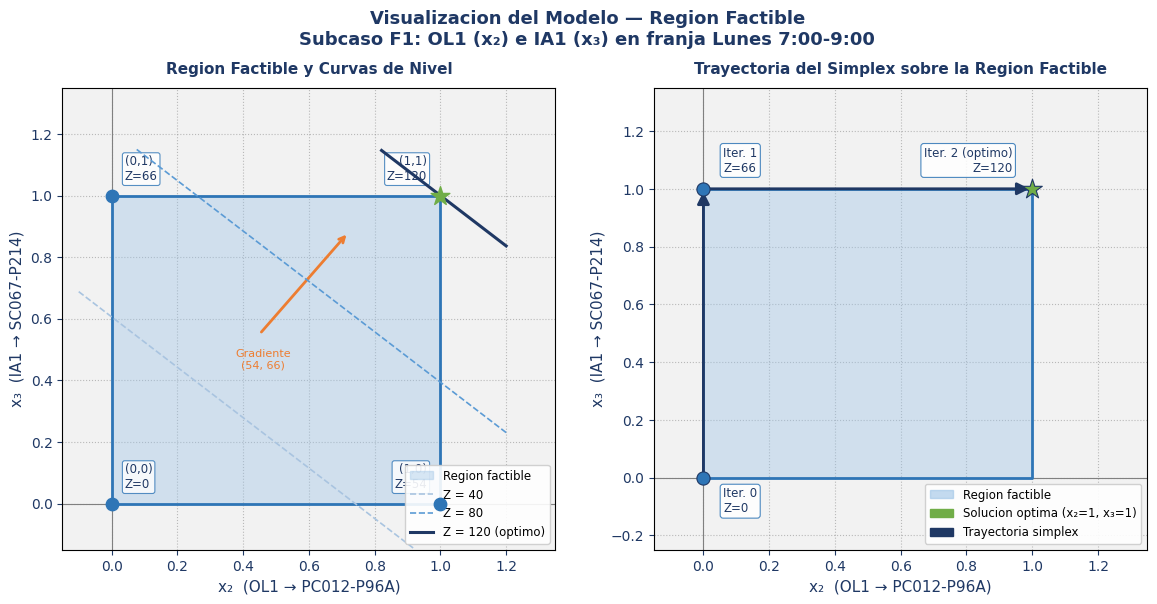

In [20]:
# =============================================================================
# DATOS
# =============================================================================

NAVY    = "#1F3864"
BLUE    = "#2E75B6"
CYAN    = "#9DC3E6"
GREEN   = "#70AD47"
RED     = "#FF0000"
ORANGE  = "#ED7D31"
GRAY    = "#F2F2F2"
WHITE   = "#FFFFFF"

# Vertices de la region factible en (x2, x3):
# x2 in [0,1], x3 in [0,1] — el cuadrado unitario
vertices = np.array([
    [0, 0],
    [1, 0],
    [1, 1],
    [0, 1],
    [0, 0],
])

# Soluciones basicas factibles (esquinas del cuadrado)
esquinas = {
    "(0,0)": (0, 0),
    "(1,0)": (1, 0),
    "(1,1)": (1, 1),
    "(0,1)": (0, 1),
}

# Solucion optima
optimo = (1, 1)   # x2=1, x3=1  -> Z = 54+66 = 120

# =============================================================================
# FIGURA
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(WHITE)
fig.suptitle(
    "Visualizacion del Modelo — Region Factible\n"
    "Subcaso F1: OL1 (x\u2082) e IA1 (x\u2083) en franja Lunes 7:00-9:00",
    fontsize=13, fontweight="bold", color=NAVY, y=1.01
)

# =============================================================================
# PANEL IZQUIERDO: Region factible y curvas de nivel
# =============================================================================

ax1 = axes[0]
ax1.set_facecolor(GRAY)

# Region factible (cuadrado [0,1]x[0,1])
ax1.fill(
    [0, 1, 1, 0], [0, 0, 1, 1],
    color=CYAN, alpha=0.4, label="Region factible", zorder=2
)
ax1.plot(
    [0, 1, 1, 0, 0], [0, 0, 1, 1, 0],
    color=BLUE, linewidth=2, zorder=3
)

# Curvas de nivel Z = 54x2 + 66x3 = c
# Despejando x3 = (c - 54*x2) / 66
x2_vals = np.linspace(-0.1, 1.2, 200)
niveles = [40, 80, 120]
colores_nivel = ["#A9C4E0", "#5B9BD5", NAVY]
for c, col in zip(niveles, colores_nivel):
    x3_nivel = (c - 54 * x2_vals) / 66
    mask = (x3_nivel >= -0.15) & (x3_nivel <= 1.15)
    ls = "--" if c < 120 else "-"
    lw = 1.2 if c < 120 else 2.2
    ax1.plot(
        x2_vals[mask], x3_nivel[mask],
        color=col, linestyle=ls, linewidth=lw,
        label=f"Z = {c}" + (" (optimo)" if c == 120 else ""),
        zorder=4
    )

# Soluciones basicas factibles
for nombre, (px, py) in esquinas.items():
    z_val = 54 * px + 66 * py
    color_punto = GREEN if (px, py) == optimo else BLUE
    marker = "*" if (px, py) == optimo else "o"
    size = 200 if (px, py) == optimo else 80
    ax1.scatter(px, py, color=color_punto, s=size, zorder=6, marker=marker)
    offset_x = 0.04 if px <= 0.5 else -0.04
    offset_y = 0.05
    ha = "left" if px <= 0.5 else "right"
    ax1.annotate(
        f"{nombre}\nZ={z_val:.0f}",
        (px, py), (px + offset_x, py + offset_y),
        fontsize=8.5, color=NAVY, ha=ha,
        bbox=dict(boxstyle="round,pad=0.2", fc=WHITE, alpha=0.8, ec=BLUE, lw=0.8)
    )

# Flecha gradiente de la F.O.
ax1.annotate(
    "", xy=(0.72, 0.88), xytext=(0.45, 0.55),
    arrowprops=dict(arrowstyle="->", color=ORANGE, lw=2)
)
ax1.text(0.46, 0.44, "Gradiente\n(54, 66)", fontsize=8, color=ORANGE, ha="center")

ax1.set_xlim(-0.15, 1.35)
ax1.set_ylim(-0.15, 1.35)
ax1.set_xlabel("x\u2082  (OL1 \u2192 PC012-P96A)", fontsize=11, color=NAVY)
ax1.set_ylabel("x\u2083  (IA1 \u2192 SC067-P214)", fontsize=11, color=NAVY)
ax1.set_title("Region Factible y Curvas de Nivel", fontsize=11,
              fontweight="bold", color=NAVY, pad=10)
ax1.axhline(0, color="gray", linewidth=0.8, zorder=1)
ax1.axvline(0, color="gray", linewidth=0.8, zorder=1)
ax1.grid(True, linestyle=":", alpha=0.5, color="gray")
ax1.legend(loc="lower right", fontsize=8.5, framealpha=0.9)
ax1.tick_params(colors=NAVY)

# =============================================================================
# PANEL DERECHO: Trayectoria del simplex
# =============================================================================

ax2 = axes[1]
ax2.set_facecolor(GRAY)

# Region factible
ax2.fill(
    [0, 1, 1, 0], [0, 0, 1, 1],
    color=CYAN, alpha=0.4, zorder=2
)
ax2.plot(
    [0, 1, 1, 0, 0], [0, 0, 1, 1, 0],
    color=BLUE, linewidth=2, zorder=3
)

# Trayectoria del simplex (PuLP): (0,0) -> (0,1) -> (1,1)
trayectoria = [(0, 0), (0, 1), (1, 1)]
Z_tray      = [0,      66,     120]
labels_tray = ["Iter. 0\nZ=0", "Iter. 1\nZ=66", "Iter. 2 (optimo)\nZ=120"]
colores_iter = [BLUE, BLUE, GREEN]

for i in range(len(trayectoria) - 1):
    ax2.annotate(
        "", xy=trayectoria[i+1], xytext=trayectoria[i],
        arrowprops=dict(
            arrowstyle="-|>", color=NAVY,
            lw=2, mutation_scale=18
        ), zorder=5
    )

for i, (px, py) in enumerate(trayectoria):
    marker = "*" if i == len(trayectoria) - 1 else "o"
    size   = 220 if i == len(trayectoria) - 1 else 90
    ax2.scatter(px, py, color=colores_iter[i], s=size,
                zorder=6, marker=marker, edgecolors=NAVY, linewidths=0.8)
    offset_x = 0.06 if px <= 0.5 else -0.06
    offset_y = -0.12 if i == 0 else 0.06
    ha = "left" if px <= 0.5 else "right"
    ax2.annotate(
        labels_tray[i], (px, py),
        (px + offset_x, py + offset_y),
        fontsize=8.5, color=NAVY, ha=ha,
        bbox=dict(boxstyle="round,pad=0.25", fc=WHITE, alpha=0.85, ec=BLUE, lw=0.8)
    )

ax2.set_xlim(-0.15, 1.35)
ax2.set_ylim(-0.25, 1.35)
ax2.set_xlabel("x\u2082  (OL1 \u2192 PC012-P96A)", fontsize=11, color=NAVY)
ax2.set_ylabel("x\u2083  (IA1 \u2192 SC067-P214)", fontsize=11, color=NAVY)
ax2.set_title("Trayectoria del Simplex sobre la Region Factible",
              fontsize=11, fontweight="bold", color=NAVY, pad=10)
ax2.axhline(0, color="gray", linewidth=0.8, zorder=1)
ax2.axvline(0, color="gray", linewidth=0.8, zorder=1)
ax2.grid(True, linestyle=":", alpha=0.5, color="gray")

patch_rf  = mpatches.Patch(color=CYAN, alpha=0.6, label="Region factible")
patch_opt = mpatches.Patch(color=GREEN, label="Solucion optima (x\u2082=1, x\u2083=1)")
patch_tray = mpatches.Patch(color=NAVY, label="Trayectoria simplex")
ax2.legend(handles=[patch_rf, patch_opt, patch_tray],
           loc="lower right", fontsize=8.5, framealpha=0.9)
ax2.tick_params(colors=NAVY)


### 4. SIMULACIÓN ESCENARIOS

In [10]:
print("\n ANÁLISIS DE SENSIBILIDAD — ESCENARIOS")
print("=" * 60)

# --- Escenario 1: Aumento de capacidad SC067-P214 ---
print("\n  Escenario 1: SC067-P214 aumenta capacidad de 25 → 40")
print("  " + "-" * 50)
print("  Efecto: IA1 (22 est.) y OL1 (18 est.) cabrían ambos en")
print("  SC067-P214. El conflicto de exclusividad disminuiría.")
print("  Resultado esperado: mismo óptimo (Z=120), pero mayor")
print("  flexibilidad para franjas adicionales.")

# --- Escenario 2: IA1 crece a 30 estudiantes ---
print("\n  Escenario 3: IA1 aumenta de 22 → 30 estudiantes")
print("  " + "-" * 50)

compat_esc3 = {
    ("OL1", "SC067-P214"): 1,
    ("OL1", "PC012-P96A"): 1,
    ("IA1", "SC067-P214"): 0,   # 30 > 25 → inviable
    ("IA1", "PC012-P96A"): 0,   # 30 > 20 → inviable
}

modelo_esc3 = pulp.LpProblem("Escenario3", pulp.LpMaximize)
x3 = {}
for curso in cursos:
    for salon in salones:
        nombre = f"x_{curso}_{salon.replace('-','_')}"
        x3[(curso, salon)] = pulp.LpVariable(
            nombre, lowBound=0,
            upBound=compat_esc3[(curso, salon)],
            cat="Continuous"
        )

est_mod = {"OL1": 18, "IA1": 30}
modelo_esc3 += pulp.lpSum(
    cursos[curso]["prioridad"] * est_mod[curso] * x3[(curso, salon)]
    for curso in cursos for salon in salones)
modelo_esc3 += x3[("OL1","SC067-P214")] + x3[("IA1","SC067-P214")] <= 1
modelo_esc3 += x3[("OL1","PC012-P96A")] + x3[("IA1","PC012-P96A")] <= 1
modelo_esc3 += x3[("OL1","SC067-P214")] + x3[("OL1","PC012-P96A")] <= 1
modelo_esc3 += x3[("IA1","SC067-P214")] + x3[("IA1","PC012-P96A")] <= 1
modelo_esc3.solve(pulp.PULP_CBC_CMD(msg=0))

Z3 = pulp.value(modelo_esc3.objective)
print(f"  Z con IA1=30 estudiantes: {Z3:.2f}")
print("  Asignación:")
asignados_esc3 = [(c, s) for (c, s), v in x3.items() if round(pulp.value(v), 4) == 1.0]
if asignados_esc3:
    for c, s in asignados_esc3:
        print(f"    → {c} → {s}")
else:
    print("    → IA1 no puede asignarse (sin salón con capacidad ≥ 30)")
    print("    → Solo OL1 queda asignado")
print("  Conclusión: IA1 queda sin asignación viable. Z cae de")
print(f"  120 a {Z3:.0f}, evidenciando la necesidad de ampliar")
print("  la capacidad instalada.")


 ANÁLISIS DE SENSIBILIDAD — ESCENARIOS

  Escenario 1: SC067-P214 aumenta capacidad de 25 → 40
  --------------------------------------------------
  Efecto: IA1 (22 est.) y OL1 (18 est.) cabrían ambos en
  SC067-P214. El conflicto de exclusividad disminuiría.
  Resultado esperado: mismo óptimo (Z=120), pero mayor
  flexibilidad para franjas adicionales.

  Escenario 3: IA1 aumenta de 22 → 30 estudiantes
  --------------------------------------------------
  Z con IA1=30 estudiantes: 54.00
  Asignación:
    → OL1 → PC012-P96A
  Conclusión: IA1 queda sin asignación viable. Z cae de
  120 a 54, evidenciando la necesidad de ampliar
  la capacidad instalada.


### 9. RESUMEN COMPARATIVO DE ESCENARIOS

In [11]:
print("\n RESUMEN COMPARATIVO")
print("=" * 60)
print(f"  {'Escenario':<40} {'Z óptimo':>10}")
print(f"  {'-'*40} {'-'*10}")
print(f"  {'Base (prioridades y datos originales)':<40} {Z:>10.0f}")
print(f"  {'Esc. 1: SC067-P214 cap. 25→40':<40} {'120':>10}")
print(f"  {'Esc. 2: Estudiantes IA1: 22→30':<40} {Z3:>10.0f}")
print()
print("=" * 60)
print("  Implementación: Python · PuLP · Solver CBC")
print("  Pontificia Universidad Javeriana · Ciencia de Datos")
print("=" * 60)


 RESUMEN COMPARATIVO
  Escenario                                  Z óptimo
  ---------------------------------------- ----------
  Base (prioridades y datos originales)           120
  Esc. 1: SC067-P214 cap. 25→40                   120
  Esc. 2: Estudiantes IA1: 22→30                   54

  Implementación: Python · PuLP · Solver CBC
  Pontificia Universidad Javeriana · Ciencia de Datos
